In [1]:
from pathlib import Path
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import ExpPatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior

seed = 42
rng = np.random.default_rng(seed)

In [2]:
basepath = Path("/src/project/data/experiment")
patterns_path = basepath / "custom_centered_exc_crops.npy"
patterns = np.load(patterns_path)
patterns = patterns - patterns.mean(axis=0)
vmin = patterns.min()
vmax = patterns.max()

In [60]:
G_dim = len(patterns)
G_prob = 0.2
I_sigma = 30
patterns_offset = 4

offset_x_1 = 0
offset_x_2 = 1
scale_x = 0.1
exponent_x = 3
zero_threshold_x = 0.05

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 300
n_draws = 300
n_chains = 4
n_cores = 4

In [61]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    offset_x_1=offset_x_1,
    offset_x_2=offset_x_2,
    scale_x=scale_x,
    exponent_x=exponent_x,
    zero_threshold_x=zero_threshold_x,
)

In [62]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

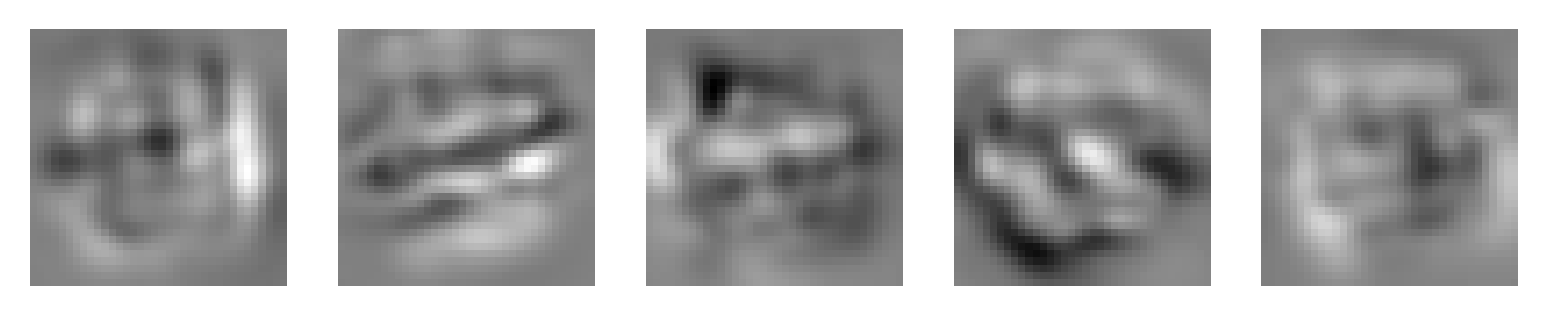

In [63]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

Text(0.5, 1.0, 'Cos sim between assigned Gs')

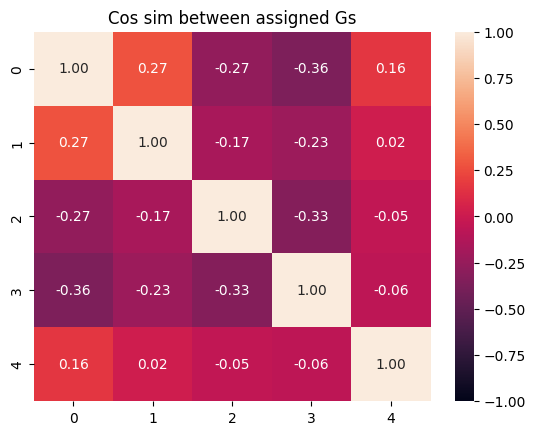

In [64]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

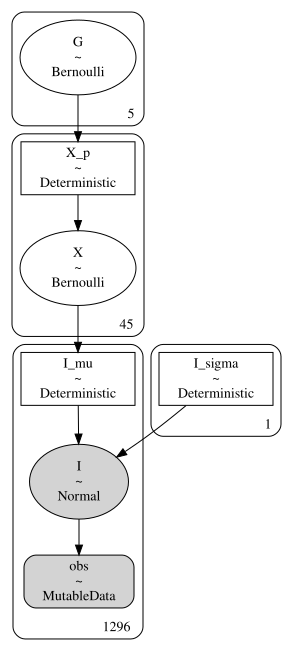

In [65]:
pm.model_to_graphviz(model.prob_model)

In [66]:
prior_samples_dict = model.sample_prior_predictive(n_samples=100, random_seed=1)

Sampling: [G, I, X]


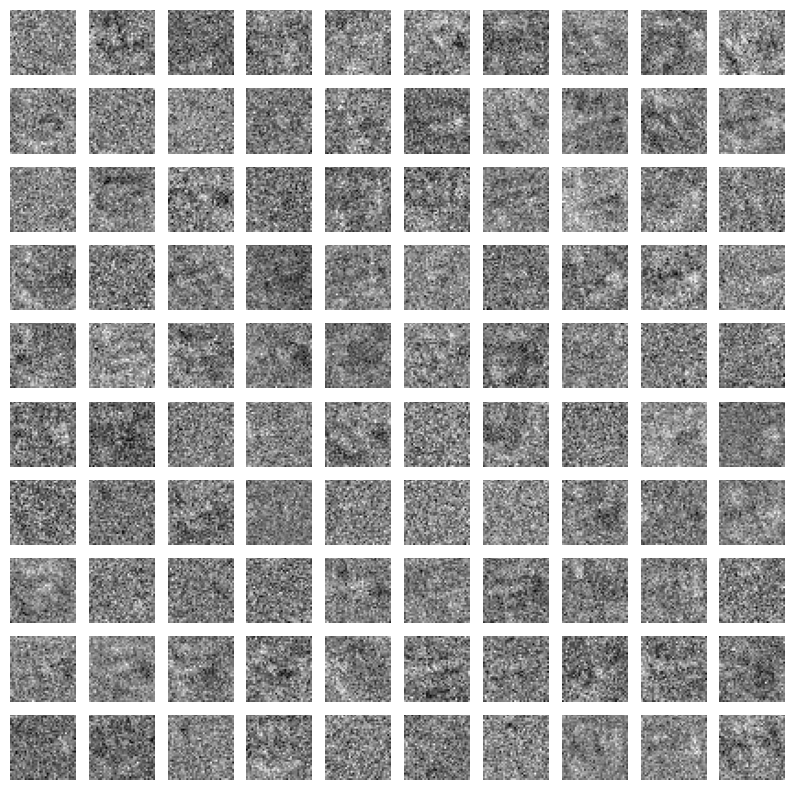

In [67]:
fig, axs = plt.subplots(10, 10, figsize=(10, 10))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(prior_samples_dict["I"][idx], cmap="gray")
    ax.axis("off")

In [68]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

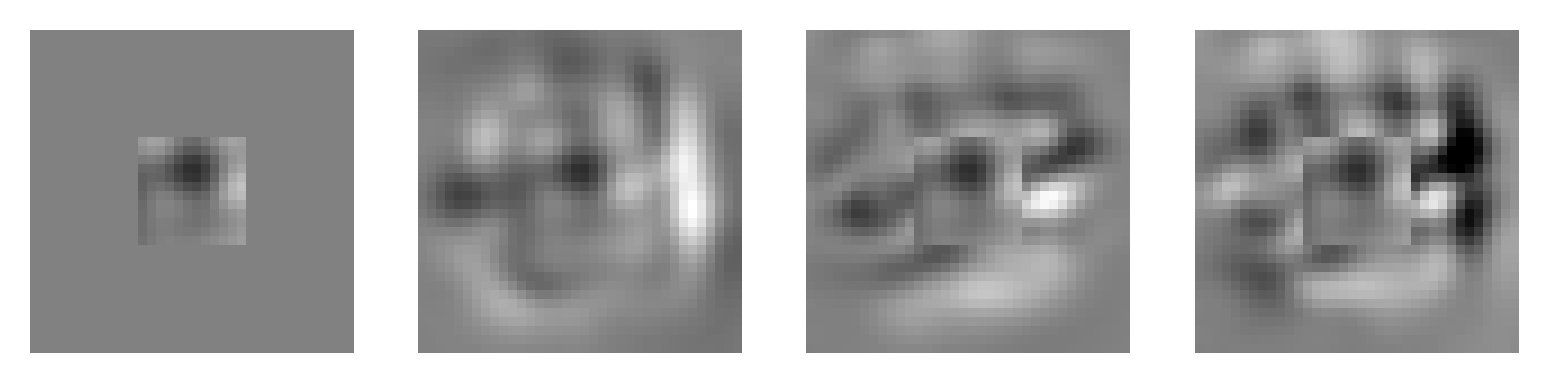

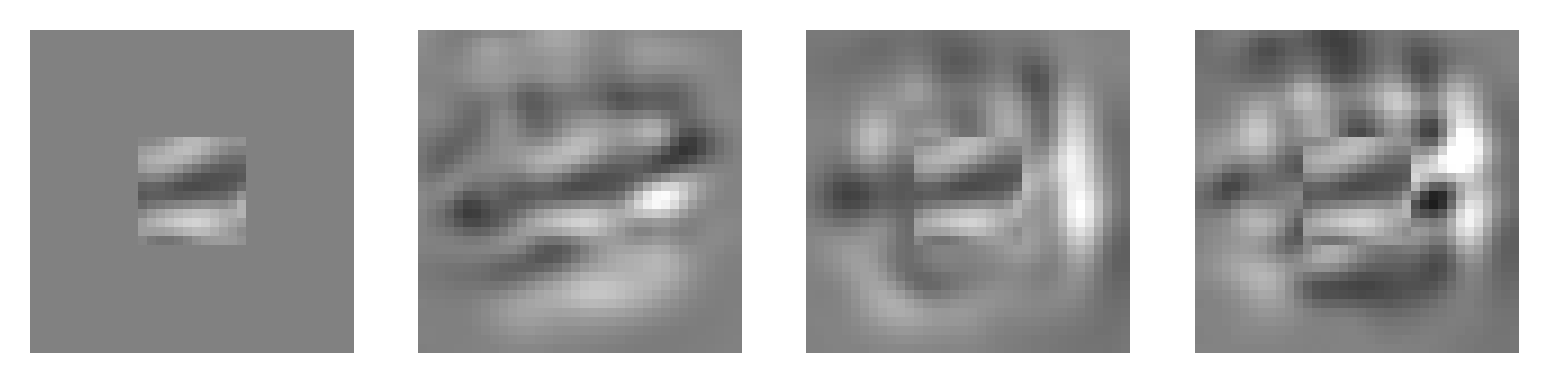

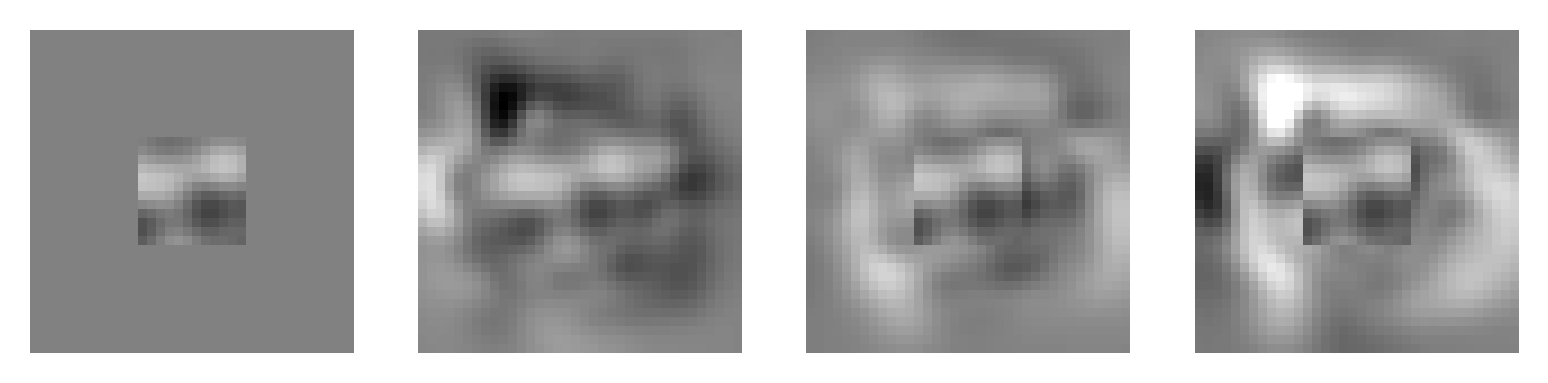

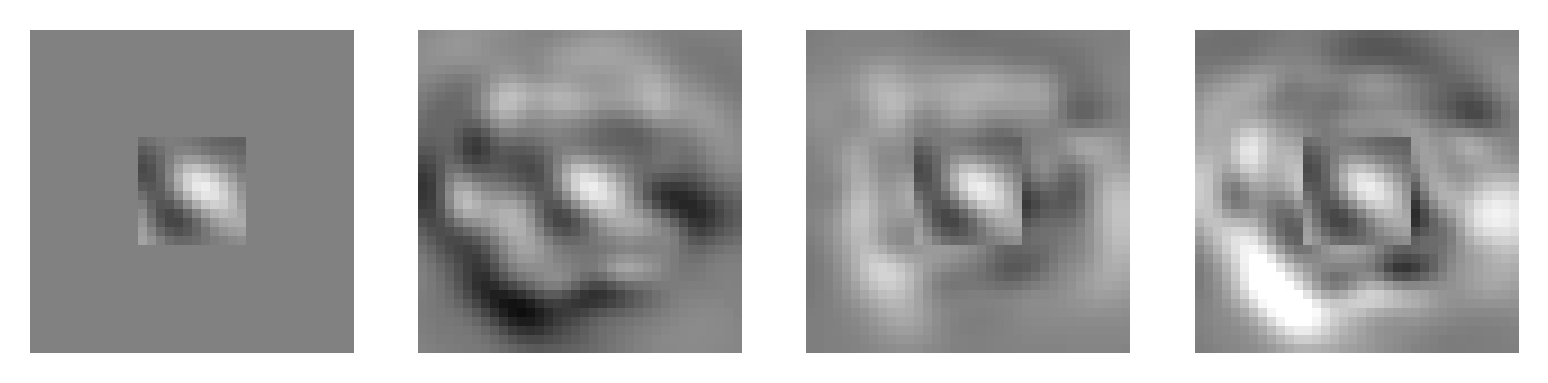

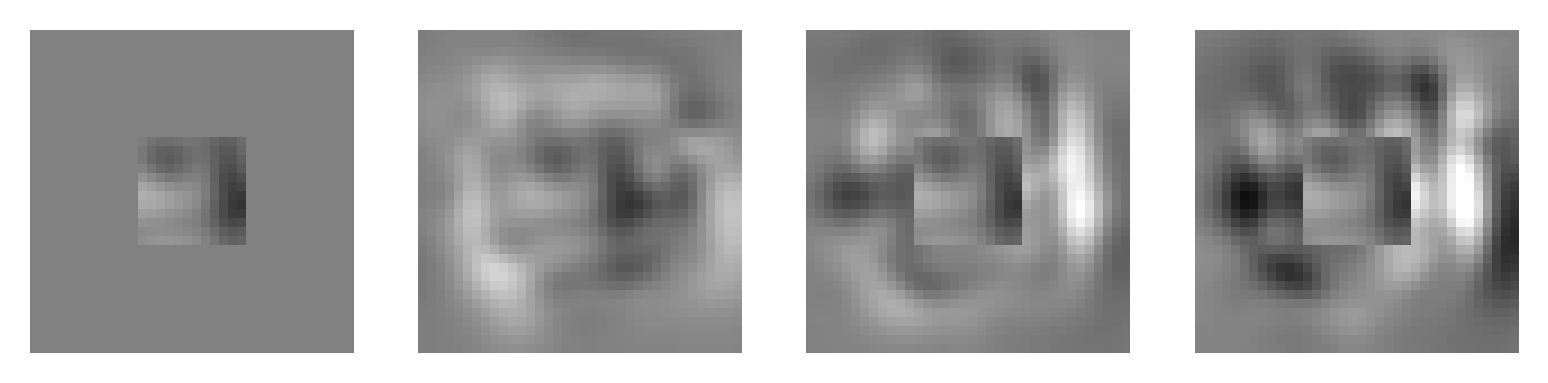

In [69]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

In [70]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    # break


Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 22 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 25 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 22 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 26 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


...

Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 43 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 41 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 45 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 36 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 300 samples in chain.
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 300 tune and 300 draw iterations (1_200 + 1_200 draws total) took 32 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [71]:
def plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata):
    """
    Modified function to plot bar plots of MEI, Completing, and Disrupting patterns for binary X
    in the same subplot for each latent variable G.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.
    - completing_perc_diff_list (list): List of percentage differences for Completing.
    - disrupting_1_perc_diff_list (list): List of percentage differences for Disrupting 1.
    - disrupting_2_perc_diff_list (list): List of percentage differences for Disrupting 2.
    """

    fig, axs = plt.subplots(
        G_dim, 6, figsize=(6 * 8, 3 * 4), tight_layout=True, sharex="col", sharey="row"
    )
    legend_size = 6

    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []

    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx

        # Collect probabilities for MEI, Completing, and Disrupting patterns
        center_probabilities = []
        all_probabilities = []
        for pattern_id, idata in enumerate(idata_set):
            x_prob = idata["posterior"]["X"].data[:, :, center_x_id].mean()
            center_probabilities.append(x_prob)
            all_x_prob = idata["posterior"]["X"].data.mean(axis=0).mean(axis=0)
            all_probabilities.append(all_x_prob)

            if pattern_id == 0:
                mei_x_prob = x_prob
            elif pattern_id > 0:
                perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100
                if pattern_id == 1:
                    completing_perc_diff_list.append(perc_diff)
                elif pattern_id == 2:
                    disrupting_1_perc_diff_list.append(perc_diff)
                elif pattern_id == 3:
                    disrupting_2_perc_diff_list.append(perc_diff)
            # if idx == 3:
            #     print(idata["posterior"]["X"].data[:, :, center_x_id])
            #     print(center_probabilities)
    
        # Plot center_probabilities in the same subplot for comparison
        ax_set[0].bar(['MEI', 'Completing', 'Disrupting 1', 'Disrupting 2'], center_probabilities, color=['blue', 'green', 'orange', 'red'])
        ax_set[0].set_ylim(0, 1)  # Probabilities range from 0 to 1

        # Plot all_probabilities in the same subplot for comparison
        for idx, probs in enumerate(all_probabilities):
            ax_set[2 + idx].bar(list(range(G_dim * 9)), probs, color=['red' if i == center_x_id else 'blue' for i in range(G_dim * 9)])
            ax_set[2 + idx].set_xticks(list(range(G_dim * 9)))
            ax_set[2 + idx].set_xticklabels(list(range(G_dim * 9)))


        # Plot G distributions (unchanged)
        mei_g_samples = idata_set[0]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        completing_g_samples = idata_set[1]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        disrupting_1_g_samples = idata_set[2]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        disrupting_2_g_samples = idata_set[3]["posterior"]["G"].data.mean(axis=0).mean(axis=0)

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim, height=completing_g_samples, width=0.8, color="green")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim * 2, height=disrupting_1_g_samples, width=0.8, color="orange")
        ax_set[1].bar(x=np.arange(G_dim) + G_dim * 3, height=disrupting_2_g_samples, width=0.8, color="red")
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

        

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

In [72]:
disrupting_pattern_indices

[1, 0, 4, 4, 0]

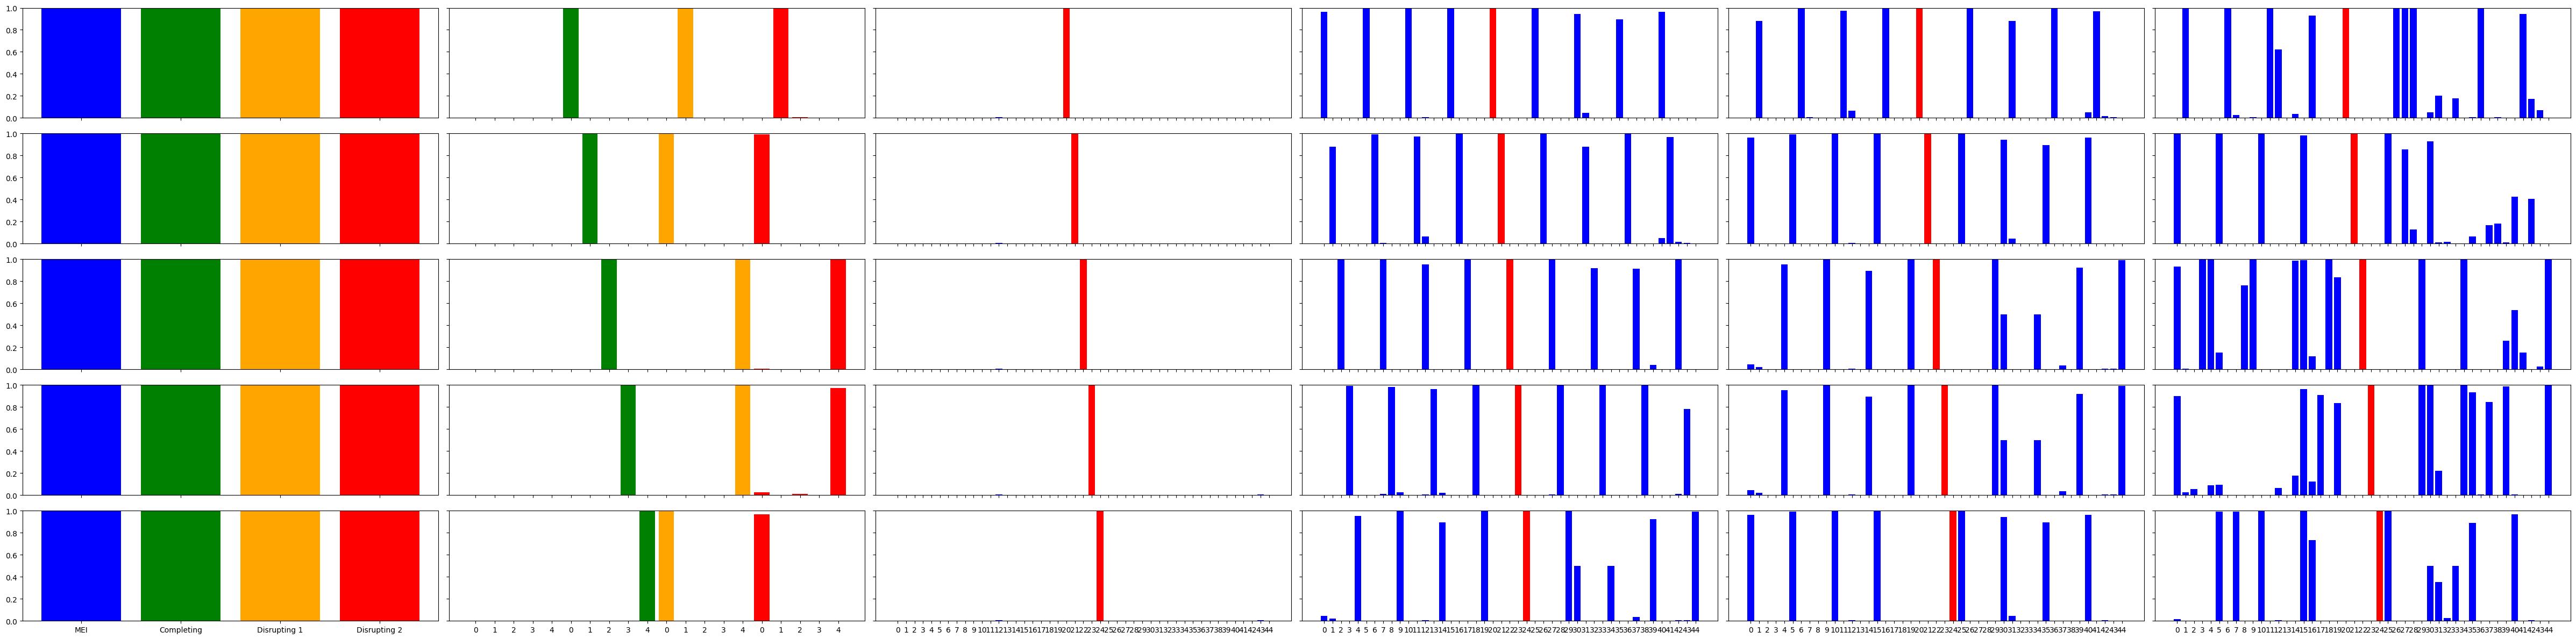

In [73]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [74]:
completing_perc_diff_list

array([0.08340284, 0.        , 0.        , 0.        , 0.        ])

In [75]:
disrupting_1_perc_diff_list

array([0., 0., 0., 0., 0.])

In [19]:
disrupting_2_perc_diff_list

array([120.28985507])

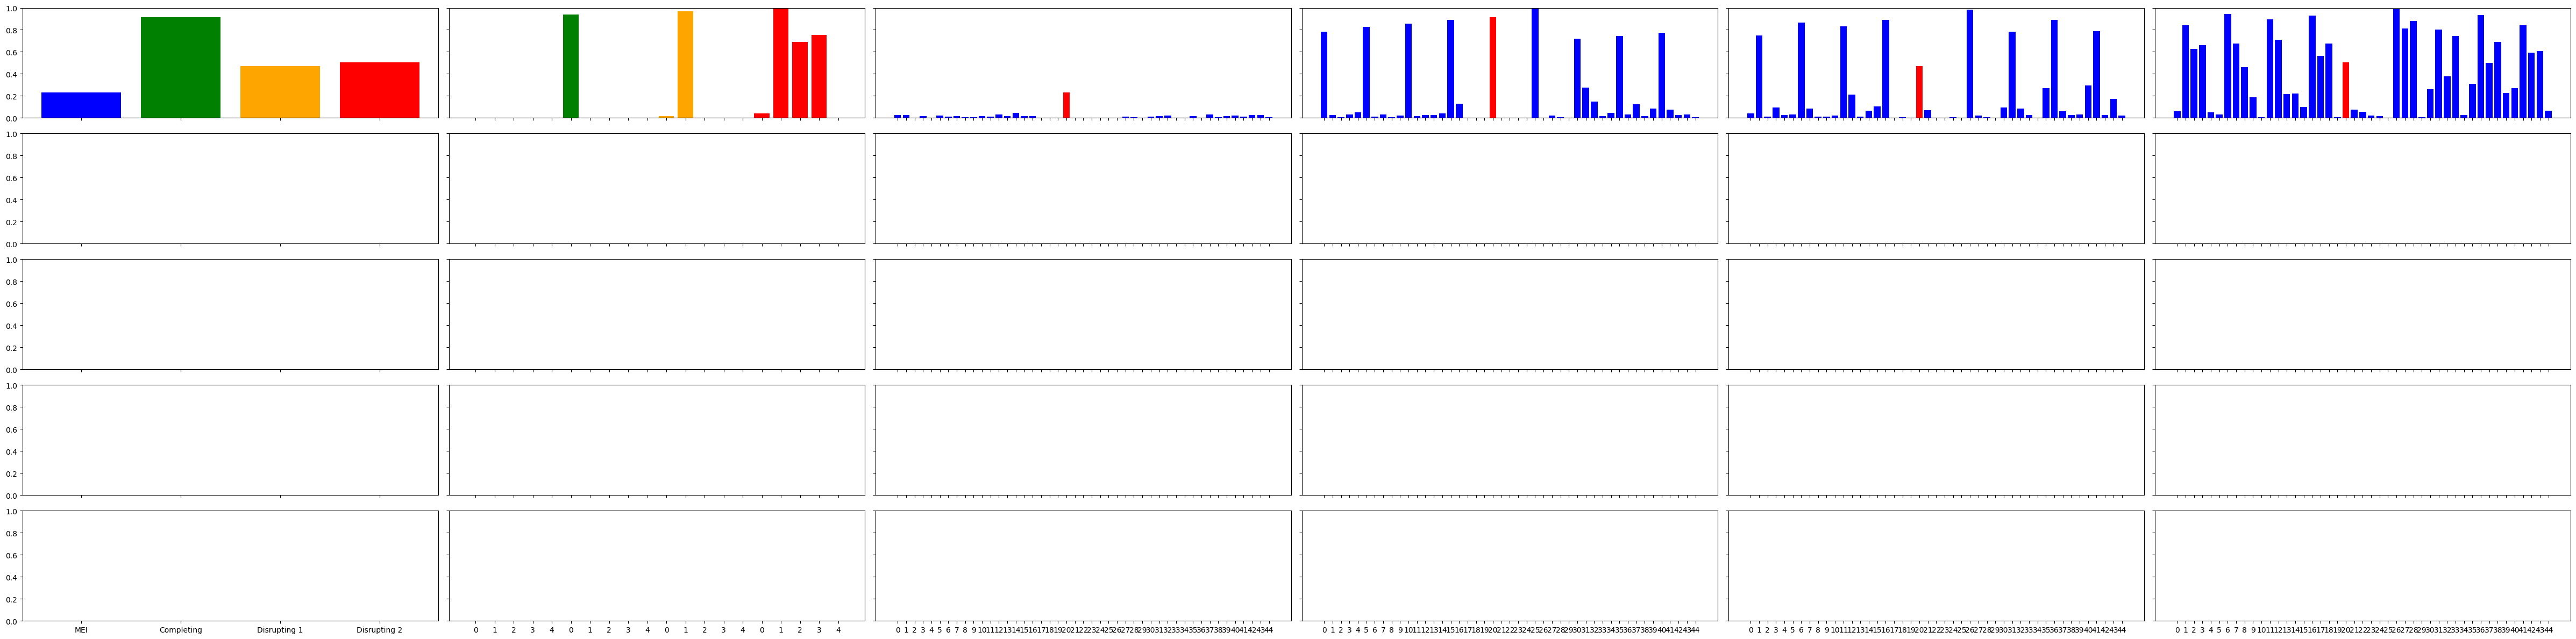

In [20]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

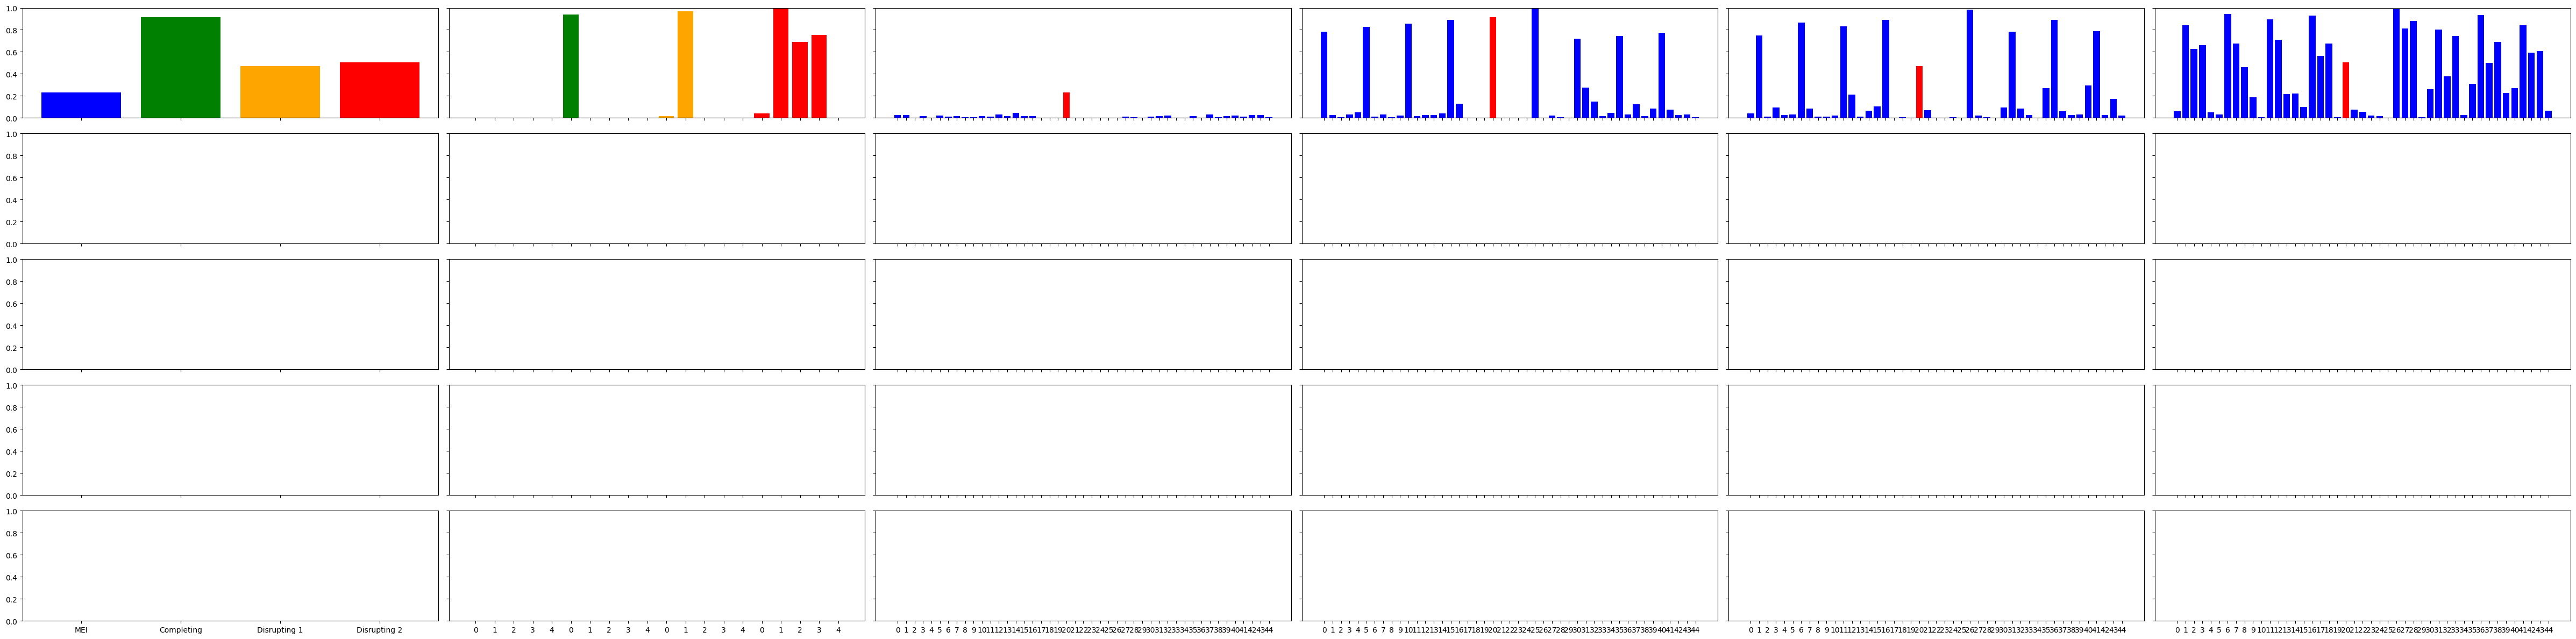

In [21]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [22]:
completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list

(array([296.73913043]), array([103.62318841]), array([120.28985507]))

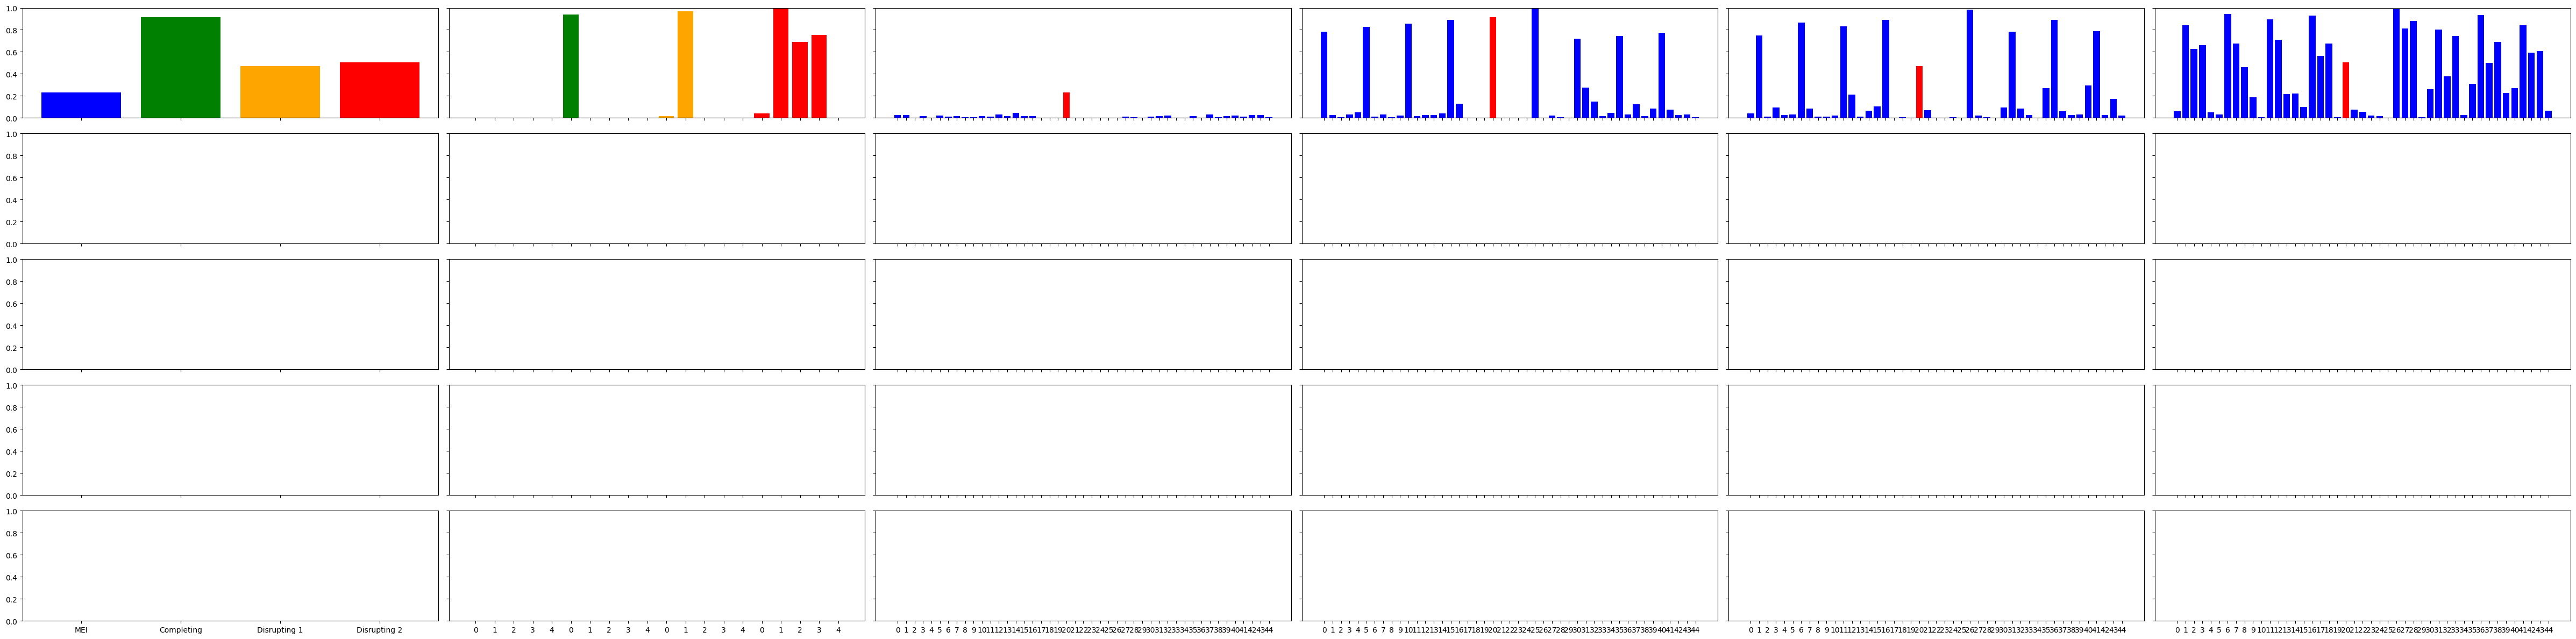

In [23]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [24]:
disrupting_1_perc_diff_list

array([103.62318841])

In [25]:
completing_perc_diff_list

array([296.73913043])

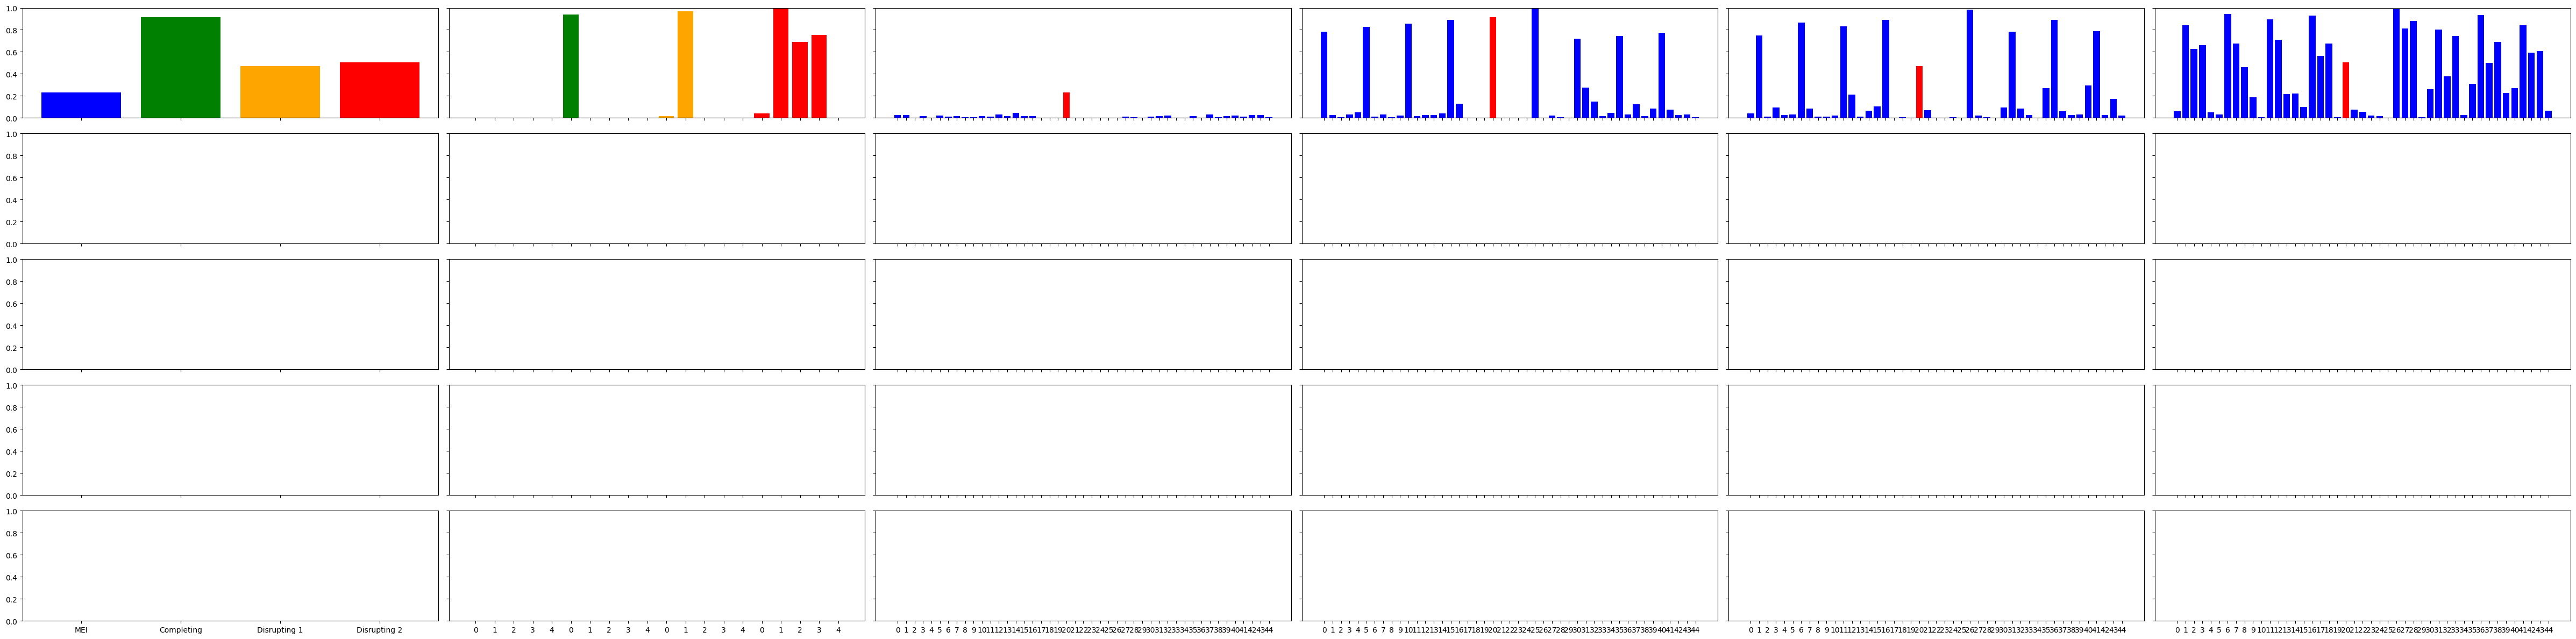

In [26]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [27]:
np.all(all_idata[0][0]['posterior']['X'].data == all_idata[1][0]['posterior']['X'].data)

IndexError: list index out of range

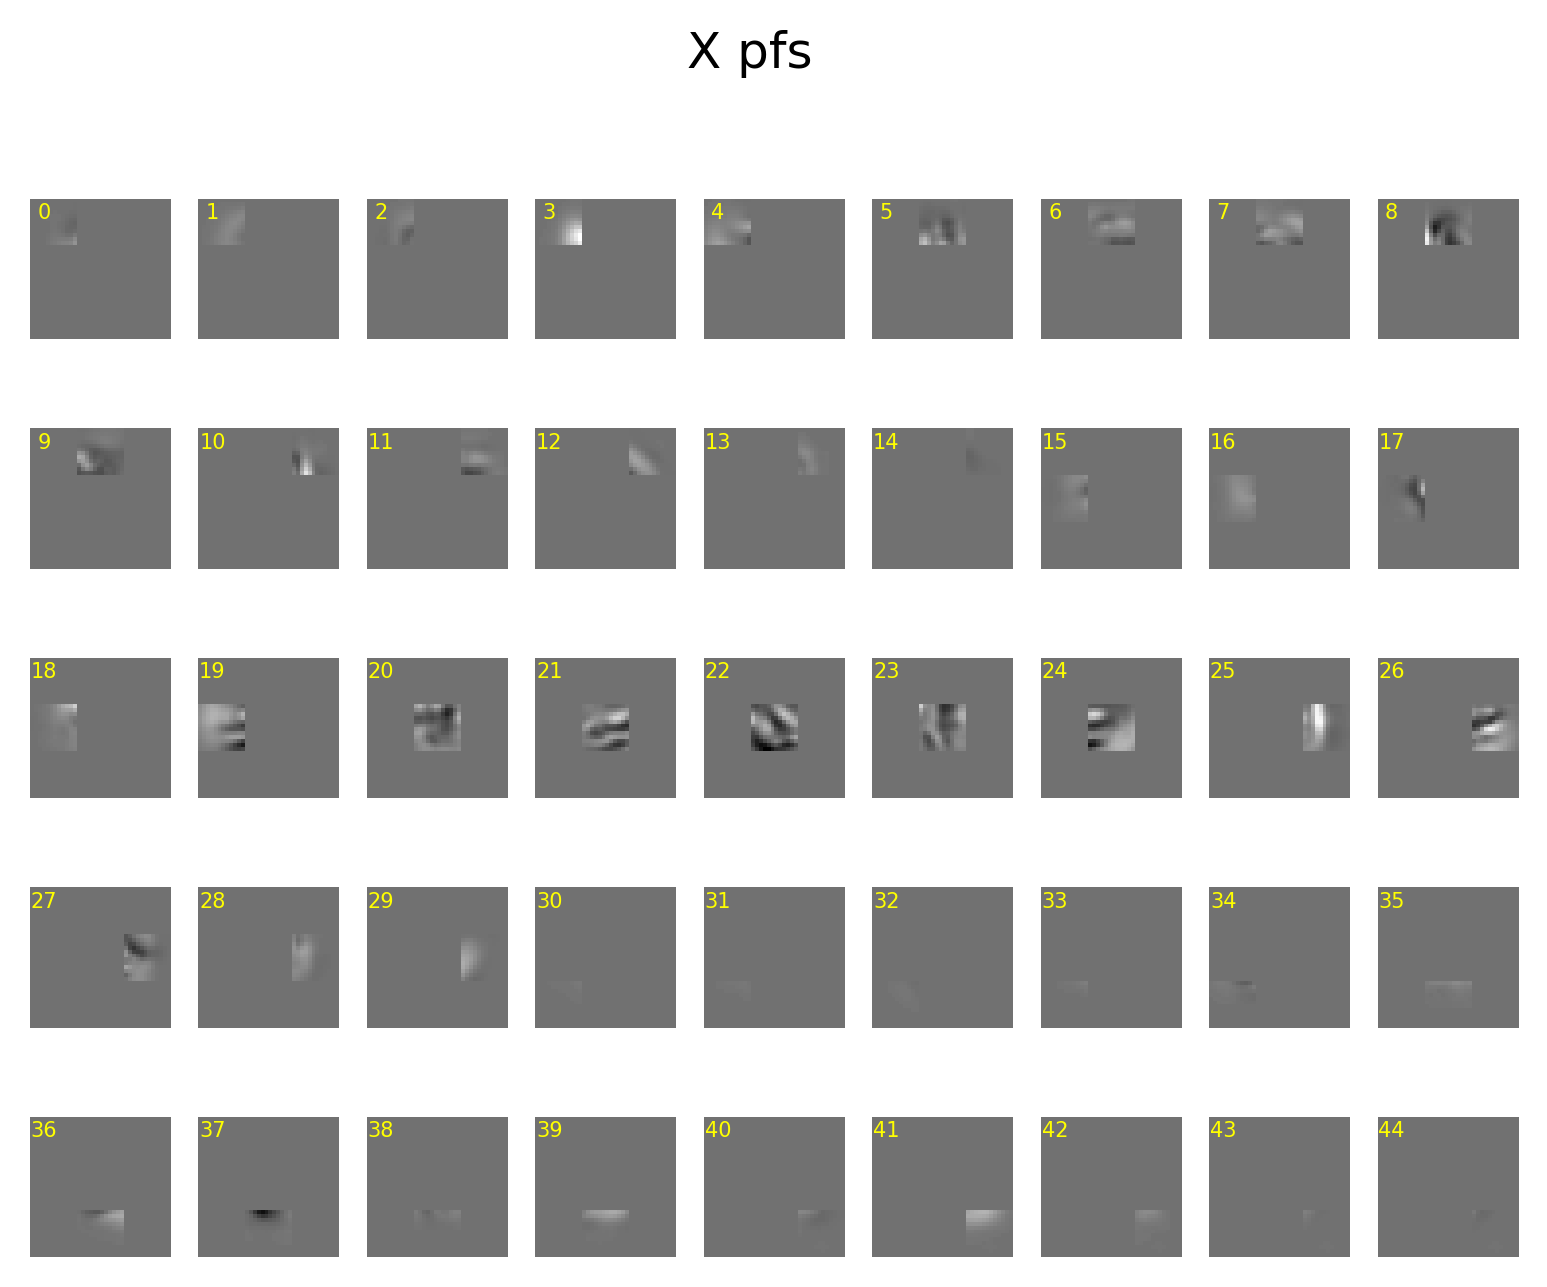

In [ ]:
images = model.visualize_learned_X(nrows=x_visual_nrows, ncols=x_visual_ncols)

(-0.5, 35.5, 35.5, -0.5)

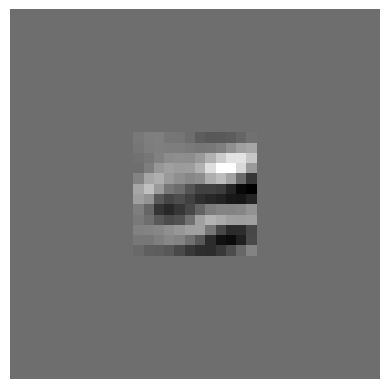

In [ ]:
plt.imshow(MEIs[1], cmap="gray")
plt.axis("off")